# Applying the XGBoost Algorithm

So far you've learned to apply a variety of different models. In this notebook you should prepare the data, import the XGBClassifier, train it and make predictions on your own. (Feel free to tune the hyperparameters in the end using a grid or random search!). 

We'll use the pima-native-americans-diabetic dataset for this task. You can find it in the data folder. You will see that the dataset is lacking column names. Therefore we added them as a list in one of the cells below. Have a look at the documentation. It is possible to import the data and directly add the columns names (they are in the correct order). 

If you need help or inspiration you can have a look at this [blogpost](https://machinelearningmastery.com/develop-first-xgboost-model-python-scikit-learn/), describing how to use the XGBoost Algorithm. 

## Learning Objectives

At the end of this notebook, you should be able to:

- Train an XGBoost classifier on a real medical dataset.
- Evaluate a classifier with a classification report and a confusion matrix.
- Rank feature importances to see which inputs drive the predictions.
- Map and visualise a model's decision surface over a grid of feature values.

## Import and Setup

In [4]:
from xgboost import XGBClassifier

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

RSEED = 42

In [5]:
# Import data
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree_function",
    "age",
    "outcome",
]

In [6]:
df = pd.read_csv("data/pima-native-americans-diabetes.csv", names=column_names)
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
X = df.drop("outcome", axis=1)
y = df["outcome"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RSEED
)

In [9]:
xgb = XGBClassifier(random_state=RSEED, n_jobs=-1)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
y_pred = xgb.predict(X_test)

In [11]:
print(classification_report(y_test, y_pred))

print("train accuracy:", xgb.score(X_train, y_train))
print("test accuracy: ", xgb.score(X_test, y_test))

              precision    recall  f1-score   support

           0       0.81      0.73      0.77       151
           1       0.57      0.69      0.62        80

    accuracy                           0.71       231
   macro avg       0.69      0.71      0.70       231
weighted avg       0.73      0.71      0.72       231

train accuracy: 1.0
test accuracy:  0.7142857142857143


In [12]:
xgb_small = XGBClassifier(
    max_depth=2, learning_rate=0.1, random_state=RSEED, n_jobs=-1
)
xgb_small.fit(X_train, y_train)

print("train accuracy:", xgb_small.score(X_train, y_train))
print("test accuracy: ", xgb_small.score(X_test, y_test))
print(classification_report(y_test, xgb_small.predict(X_test)))

train accuracy: 0.8640595903165735
test accuracy:  0.7575757575757576
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       151
           1       0.65      0.66      0.65        80

    accuracy                           0.76       231
   macro avg       0.73      0.74      0.73       231
weighted avg       0.76      0.76      0.76       231



Text(50.83333333333333, 0.5, 'Actual')

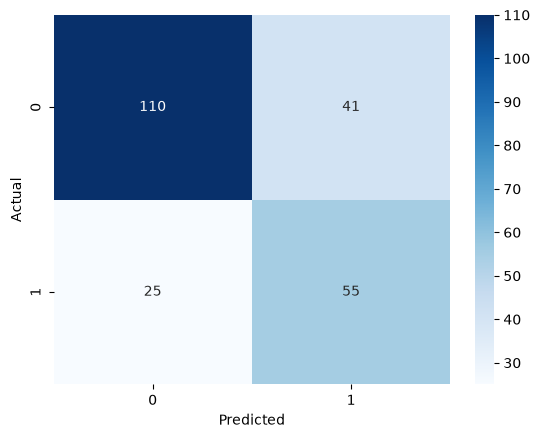

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [14]:
def make_row(row_length, row_min, row_max):
    step = (row_max - row_min) / row_length
    row = []
    for i in range(0, row_length + 1):
        row.append(row_min + (step * i))
    return row

grid = pd.DataFrame()
for i in X_train.columns:
    grid[i] = make_row(3, X_train[i].min(), X_train[i].max())

grid

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age
0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.078000,21.0
1,5.666667,66.333333,40.666667,21.0,282.0,22.366667,0.858667,41.0
2,11.333333,132.666667,81.333333,42.0,564.0,44.733333,1.639333,61.0
3,17.000000,199.000000,122.000000,63.0,846.0,67.100000,2.420000,81.0


In [15]:
from itertools import product

def make_row(row_length, row_min, row_max):
    step = (row_max - row_min) / row_length
    return [row_min + step * i for i in range(row_length + 1)]

values = {}
for col in X_train.columns:
    values[col] = make_row(3, X_train[col].min(), X_train[col].max())

full_grid = pd.DataFrame(list(product(*values.values())), columns=values.keys())

full_grid["prob"] = xgb.predict_proba(full_grid)[:, 1]
full_grid.tail()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,prob
65531,17.0,199.0,122.0,63.0,846.0,67.1,1.639333,81.0,0.898307
65532,17.0,199.0,122.0,63.0,846.0,67.1,2.420000,21.0,0.902486
65533,17.0,199.0,122.0,63.0,846.0,67.1,2.420000,41.0,0.944114
65534,17.0,199.0,122.0,63.0,846.0,67.1,2.420000,61.0,0.912643
65535,17.0,199.0,122.0,63.0,846.0,67.1,2.420000,81.0,0.898307


In [16]:
imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
imp.sort_values(ascending=False)

glucose                       0.280705
age                           0.147054
bmi                           0.140513
insulin                       0.112116
skin_thickness                0.085491
diabetes_pedigree_function    0.083250
blood_pressure                0.077050
pregnancies                   0.073823
dtype: float32

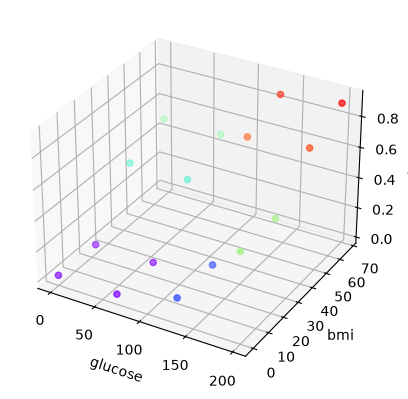

In [17]:
grid_slice = full_grid.groupby(["glucose", "bmi"], as_index=False).mean()

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter3D(grid_slice.glucose, grid_slice.bmi, grid_slice.prob,
             c=grid_slice.prob, cmap="rainbow")
ax.set_xlabel("glucose")
ax.set_ylabel("bmi")
ax.set_zlabel("probability")
plt.show()